In [73]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

import pandas as pd

centroids = [(-5,-5),(5,5),(-2.5,2.5),(2.5,-2.5)]
cluster_std = [1,1,1,1]

X,y = make_blobs(n_samples=100,cluster_std=cluster_std,centers=centroids,n_features=2,random_state=2)

In [74]:
# Algorithm for Kmeans
# 1. decide the clusters (K)
# 2. select random clusters
# 3. assign cluster
# 4. move centroids
# 5. check finish condition - last centroid position - current centroid position

In [75]:
import random
import numpy as np

class Kmeans:
    def __init__(self,n_clusters=2,max_iter=100):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.centroids = None

    def fit_predict(self,X):

        random_index = random.sample(range(0,X.shape[0]),self.n_clusters)
        self.centroids = X[random_index]

        for i in range(self.max_iter):
            # assign clusters
            cluster_group = self.assign_clusters(X)
            old_centroids = self.centroids
            # move centroids
            self.centroids = self.move_centroids(X,cluster_group)
            # check finish
            if (old_centroids == self.centroids).all():
                break

        return cluster_group

    def assign_clusters(self,X):
        cluster_group = []
        distances = []

        for row in X:
            for centroid in self.centroids:
                distances.append(np.sqrt(np.dot(row-centroid,row-centroid)))
            min_distance = min(distances)
            index_pos = distances.index(min_distance)
            cluster_group.append(index_pos)
            distances.clear()

        return np.array(cluster_group)

    def move_centroids(self,X,cluster_group):
        new_centroids = []

        cluster_type = np.unique(cluster_group)

        for type in cluster_type:
            new_centroids.append(X[cluster_group == type].mean(axis=0))

        return np.array(new_centroids)



In [76]:
df = pd.read_csv("/content/student_clustering.csv")
df.head()

,cgpa,iq
0,5.13,88
1,5.90,113
2,8.36,93
3,8.27,97
4,5.45,110


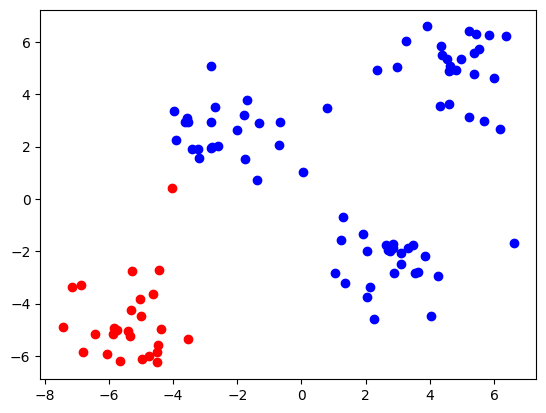

In [77]:
km = Kmeans(n_clusters=2,max_iter=100)
y_means = km.fit_predict(X)

plt.scatter(X[y_means == 0,0],X[y_means == 0,1],color='red')
plt.scatter(X[y_means == 1,0],X[y_means == 1,1],color='blue')
plt.scatter(X[y_means == 2,0],X[y_means == 2,1],color='green')
plt.scatter(X[y_means == 3,0],X[y_means == 3,1],color='yellow')
plt.show()

In [78]:
import math
import numpy as np

# Points in 3D (x, y, z)
point1 = [1, 2, 3]
point2 = [4, 5, 6]

# Using standard math library
dist_math = math.dist(point1, point2)

# Using NumPy (often faster for large data)
dist_numpy = np.linalg.norm(np.array(point1) - np.array(point2))

print(f"Distance: {dist_math}")
print(dist_numpy)


Distance: 5.196152422706632
5.196152422706632
